# Phase 0 pilot — key findings

**Setup.** TREC DL 2019 (judged), BM25 pool to depth 100; all pairs among each query's
top-10 give **1,900 canonical document pairs**. An LLM judge sees every pair in both
orders; ten lexical axioms from `ir_axioms` state their own preference on the same
pairs. Two judges were run: **Qwen 3.6 35B-A3B** (primary) and **Flan-T5-large**
(cheap contrast).

Three questions this notebook answers:

1. How often does each axiom actually *apply* to a real BM25 top-10 pair?
2. When an axiom does apply, how often does it agree with the LLM judge?
3. Is the LLM judge internally consistent enough to be worth agreeing with?

> ⚠️ **Caveat (PROX1/PROX2).** These metrics were computed from an axiom-preference
> cache written before the 2026-07-11 axiom-stage rewrite, so they inherit two
> upstream `ir_axioms` 1.1.2 bugs: the batch PROX2 path is **sign-flipped** (its
> below-chance agreement here is roughly the inverse of the true value) and PROX1 is
> hash-seed nondeterministic (one arbitrary draw). Rerun
> `experiments/p0_pilot/run.py --refresh` to regenerate; verdicts stay cached.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from axiomrank.paths import results_dir

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
COLORS = {"models/qwen3.6-35B-A3B-AWQ": "#2a78d6", "google/flan-t5-large": "#1baf7a"}
LABELS = {"models/qwen3.6-35B-A3B-AWQ": "Qwen 3.6 35B", "google/flan-t5-large": "Flan-T5-large"}
PRIMARY = "models/qwen3.6-35B-A3B-AWQ"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": INK2,
    "axes.edgecolor": BASE, "axes.grid": False, "font.size": 11,
})

metrics_root = results_dir("p0_pilot") / "metrics"
agreement, consistency = {}, {}
for d in sorted(metrics_root.iterdir()):
    model = d.name.replace("__", "/")
    agreement[model] = pd.read_csv(d / "agreement.csv").set_index("axiom")
    consistency[model] = json.loads((d / "consistency.json").read_text())

agr = pd.concat(agreement, names=["model"])
agr.loc[PRIMARY, ["coverage", "n_evaluable", "agreement"]].round(3)

,coverage,n_evaluable,agreement
axiom,,,
TFC1,0.757,1032,0.478
TFC3,0.001,2,0.500
M_TDC,0.008,12,0.833
LNC1,0.063,61,0.639
TF_LNC,0.049,75,0.547
PROX1,0.395,554,0.597
PROX2,0.498,689,0.354
PROX3,0.128,200,0.675
PROX4,0.205,302,0.639


## 1. Most axioms rarely apply to real pairs

Coverage = share of the 1,900 pairs on which the axiom expresses *any* preference
(its preconditions hold and it doesn't tie). This is the same for both judges —
it's a property of the axiom and the pool, not the model.

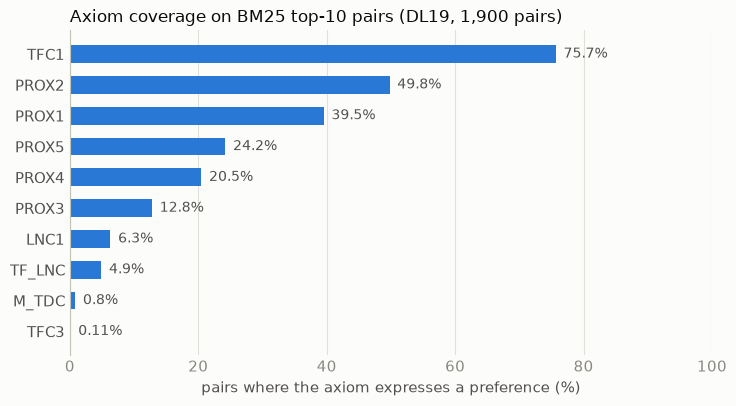

In [2]:
cov = agreement[PRIMARY]["coverage"].sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(cov.index, cov * 100, height=0.58, color="#2a78d6")
for y, v in enumerate(cov * 100):
    ax.text(v + 1.2, y, f"{v:.1f}%" if v >= 0.5 else f"{v:.2f}%",
            va="center", color=INK2, fontsize=10)
ax.set_xlim(0, 100)
ax.set_xlabel("pairs where the axiom expresses a preference (%)")
ax.set_title("Axiom coverage on BM25 top-10 pairs (DL19, 1,900 pairs)",
             loc="left", fontsize=12, color=INK)
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

Only **TFC1** (raw term-frequency) and the **PROX** family fire on a meaningful share
of real pairs. **TFC3** (2 pairs) and **M-TDC** (~10 pairs) essentially never apply
at top-10 depth — whatever agreement they show is noise, and any downstream
aggregation that weights axioms equally is really being driven by five or six axioms.

## 2. Agreement with the LLM judge, where the axiom applies

Agreement is computed only on pairs where the axiom fires *and* the judge is
decisive. The dashed line is chance (0.5). Axioms whose evaluable-pair count is
tiny (n < 30) are greyed out — their estimates are meaningless.

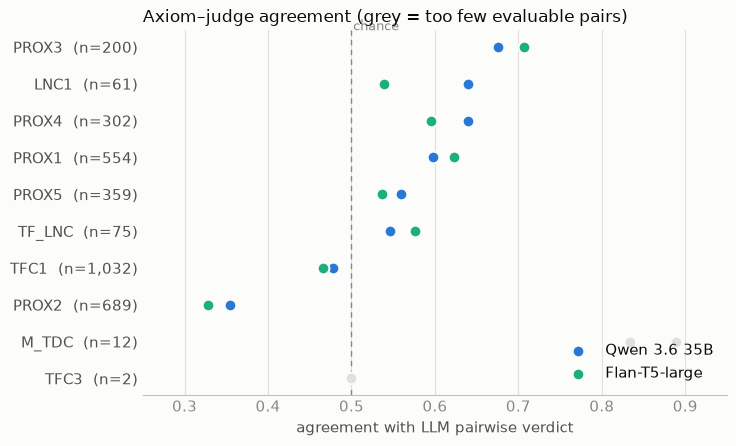

In [3]:
MIN_N = 30
order = (agreement[PRIMARY]
         .assign(reliable=lambda d: d.n_evaluable >= MIN_N)
         .sort_values(["reliable", "agreement"])
         .index.tolist())

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.axvline(0.5, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
ax.text(0.502, len(order) - 0.25, "chance", color=MUTED, fontsize=9, va="top")

for model, color in COLORS.items():
    df = agreement[model].loc[order]
    reliable = df.n_evaluable >= MIN_N
    for rel, c in [(reliable, color), (~reliable, GRID)]:
        sub = df[rel]
        ax.scatter(sub.agreement, [order.index(a) for a in sub.index],
                   s=72, color=c, edgecolors=SURFACE, linewidths=1.5, zorder=3,
                   label=LABELS[model] if rel is reliable else None)

ylabels = [f"{a}  (n={agreement[PRIMARY].loc[a, 'n_evaluable']:,})" for a in order]
ax.set_yticks(range(len(order)), ylabels)
ax.set_xlim(0.25, 0.95)
ax.set_xlabel("agreement with LLM pairwise verdict")
ax.set_title("Axiom–judge agreement (grey = too few evaluable pairs)",
             loc="left", fontsize=12, color=INK)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

Three things stand out, and they are consistent across both judges (which is itself
reassuring — the signal isn't an artefact of one model):

- **PROX3 is the best-aligned axiom** (~0.68–0.71): exact query-phrase proximity
  tracks LLM preference better than anything else tested.
- **TFC1 sits at or below chance** (~0.47) despite being the highest-coverage axiom.
  Among BM25's own top-10, "more query-term occurrences" carries no information the
  judge cares about — plausibly range restriction, since BM25 already saturated TF.
- **PROX2 is well below chance** (~0.33–0.35) — but see the caveat above: this is
  the sign-flipped batch path, so the true value is likely ~0.65 territory, which
  would make it the *second-best* axiom, not the worst.

## 3. The judge is consistent enough to be a target

Sanity checks on the LLM judge itself: does it give the same answer when the pair is
swapped, and are its preferences transitive?

In [4]:
rows = {}
for model, s in consistency.items():
    rows[LABELS[model]] = {
        "position consistency": f"{s['position_consistency']:.1%}",
        "complete triangles (of sampled)": f"{s['triangle_survival']:.1%}",
        "non-transitive triangles": f"{s['nontransitivity_rate']:.2%}",
        "mean latency / pair": f"{s['mean_latency_ms']:,.0f} ms",
    }
pd.DataFrame(rows)[["Qwen 3.6 35B", "Flan-T5-large"]]

,Qwen 3.6 35B,Flan-T5-large
position consistency,71.4%,67.1%
complete triangles (of sampled),41.5%,33.6%
non-transitive triangles,0.10%,0.35%
mean latency / pair,386 ms,"1,138 ms"


Both judges give the same verdict under order-swap on about **2 in 3 pairs**, and
where a full preference triangle survives, cycles are rare (**< 0.4%**) — pairwise
LLM preferences are close to a transitive relation on this pool. Qwen is the better
target on every count: more position-consistent (71% vs 67%), more decisive
(42% vs 34% of triangles complete), five times fewer cycles, and ~3× faster per pair.

### Takeaways

1. At top-10 depth only ~6 of 10 lexical axioms ever apply; TFC3 and M-TDC can be
   dropped from Phase 1 aggregation without loss.
2. Proximity (PROX3, and PROX2 once the sign flip is corrected) aligns with LLM
   preference; raw term frequency (TFC1) does not, on pairs BM25 already ranks highly.
3. The LLM judge is self-consistent and near-transitive enough to serve as the
   preference oracle for Phase 1 — and Qwen dominates Flan-T5 as the choice.
4. **Action item:** refresh the axiom-preference cache (`--refresh`) so PROX1/PROX2
   reflect the fixed code path before any number here goes in the thesis.